In [153]:
#importing all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
#Import the datasets
df1 = pd.read_csv('train.csv')
df2 = pd.read_csv('test.csv')

In [155]:
#Finding null values in training data
df1.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [157]:
#Finding null values in test data
df2.isnull().sum().sort_values(ascending=False)
#Finding the index which has null values in 'MasVnrType' column
df1[df1['MasVnrType'].isnull()].index

Index([   1,    3,    5,    8,    9,   10,   12,   15,   17,   18,
       ...
       1445, 1448, 1449, 1450, 1453, 1454, 1455, 1457, 1458, 1459],
      dtype='int64', length=872)

In [97]:
df1.shape, df2.shape

((1460, 81), (1459, 80))

In [98]:
#Merge the datasets for preprocessing, keep saleprice only in train set and 0 in test set
df2['SalePrice'] = 0
df = pd.concat([df1, df2], ignore_index=True)
df.shape

(2919, 81)

In [99]:
df.isnull().sum().sort_values(ascending=False)

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
                ... 
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
SalePrice          0
Length: 81, dtype: int64

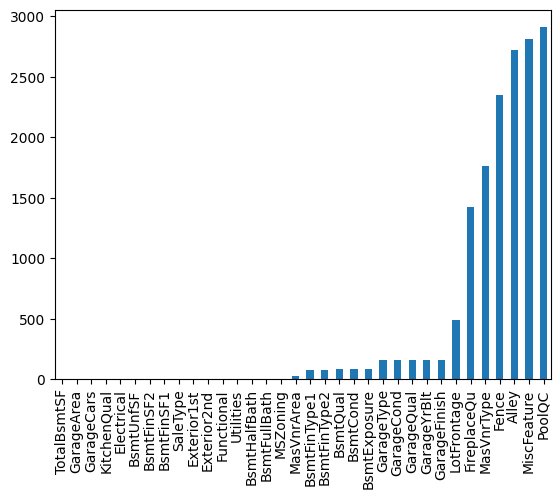

In [100]:
#Plotting a barchart of missing values across all columns
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()
plt.show()

In [101]:
#Let's drop columns called; 'Alley', 'PoolQC', 'Fence', 'MiscFeature' as they have too many missing values
df.drop(columns=['Alley', 'PoolQC', 'Fence', 'MiscFeature'], inplace=True)

In [102]:
#Let's take only categorical columns and do one hot encoding on them after dropping missing values
cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [103]:
df_cat = df[cat_cols]
df_cat = df_cat.fillna('Missing')
df_cat_encoded = pd.get_dummies(df_cat, drop_first=True)

In [104]:
#Removing all the Missing values columns from the encoded dataframe
missing_cols = [col for col in df_cat_encoded.columns if 'Missing' in col]
df_cat_encoded.drop(columns=missing_cols, inplace=True)

In [105]:
df_cat_encoded 

,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,False,False,False,True,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
2915,False,False,False,True,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2916,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2917,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False


In [106]:
#Concatenating the encoded categorical columns back to the main dataframe
df_final = pd.concat([df.drop(columns=cat_cols), df_cat_encoded], axis=1)
df_final.shape

(2919, 237)

In [107]:
df_final.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,False,False,False,False,True,False,False,False,True,False


In [108]:
df_final.shape

(2919, 237)

In [109]:
#Extracting only numeric columns
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df_final[numeric_cols].copy()
df_numeric.shape

(2919, 38)

In [110]:
df_numeric.isnull().sum().sort_values(ascending=False)[lambda x: x > 0]

LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
BsmtHalfBath      2
BsmtFullBath      2
BsmtUnfSF         1
GarageCars        1
GarageArea        1
BsmtFinSF1        1
BsmtFinSF2        1
TotalBsmtSF       1
dtype: int64

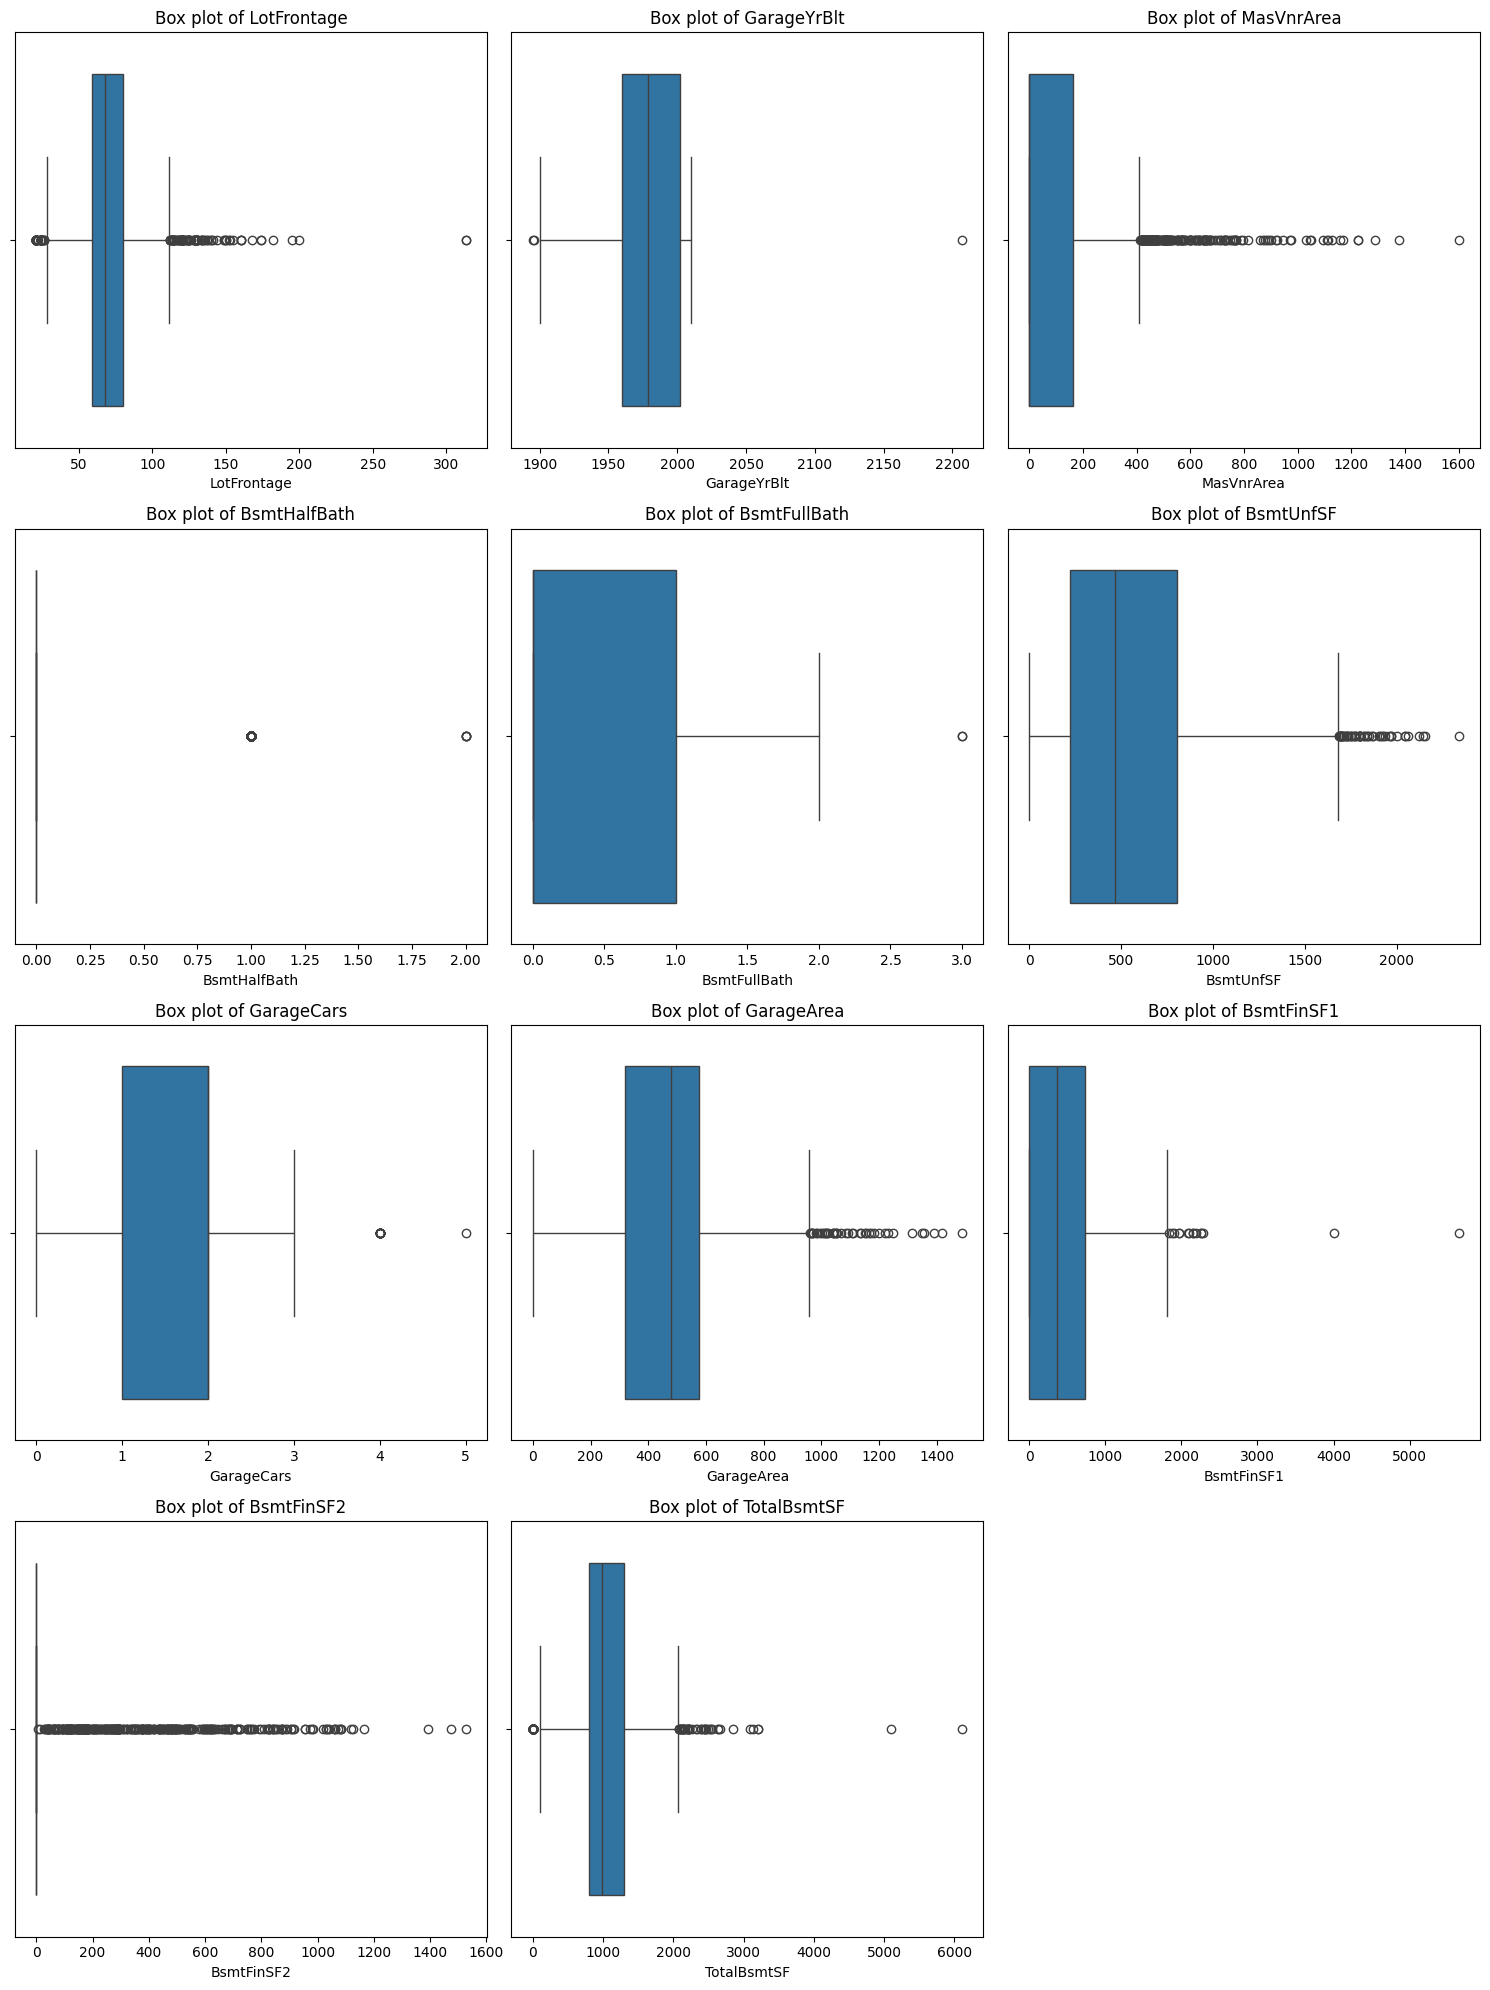

In [111]:
#Null count greater than 0 
df_numeric.isnull().sum().sort_values(ascending=False)[lambda x: x > 0]
#Plotting box plot for all of these columns to see the outliers in grid plots
cols_with_missing = df_numeric.isnull().sum().sort_values(ascending=False)[lambda x: x > 0].index.tolist()
n_cols = 3
n_rows = int(np.ceil(len(cols_with_missing) / n_cols))
plt.figure(figsize=(15, n_rows * 5))
for i, col in enumerate(cols_with_missing):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_numeric[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [112]:
df_numeric

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,21.0,1936,4,7,1970,1970,0.0,0.0,...,0,0,0,0,0,0,0,6,2006,0
2915,2916,160,21.0,1894,4,5,1970,1970,0.0,252.0,...,0,24,0,0,0,0,0,4,2006,0
2916,2917,20,160.0,20000,5,7,1960,1996,0.0,1224.0,...,474,0,0,0,0,0,0,9,2006,0
2917,2918,85,62.0,10441,5,5,1992,1992,0.0,337.0,...,80,32,0,0,0,0,700,7,2006,0


In [113]:
# LotFrontage: median by neighborhood
df_numeric['LotFrontage'] = df_numeric['LotFrontage'].fillna(df.groupby('Neighborhood')['LotFrontage'].transform('median'))

# GarageYrBlt: use YearBuilt
df_numeric['GarageYrBlt'] = df_numeric['GarageYrBlt'].fillna(df['YearBuilt'])

# MasVnrArea: fill with 0
df_numeric['MasVnrArea'] = df_numeric['MasVnrArea'].fillna(0)

# All basement variables: fill with 0
df_numeric[['BsmtHalfBath', 'BsmtFullBath', 'BsmtUnfSF', 'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF']] = df_numeric[['BsmtHalfBath', 'BsmtFullBath', 'BsmtUnfSF', 'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF']].fillna(0)

# Garage variables: fill with 0
df_numeric[['GarageCars', 'GarageArea']] = df_numeric[['GarageCars', 'GarageArea']].fillna(0)

In [115]:
df_numeric.isnull().sum().sort_values(ascending=False)[lambda x: x > 0]

Series([], dtype: int64)

In [117]:
df_final.shape

(2919, 237)

In [118]:
df_numeric.shape

(2919, 38)

In [119]:
#Merging back df_final and df_numeric to have all columns with no missing values
df_final.update(df_numeric)
df_final.isnull().sum().sort_values(ascending=False)[lambda x: x > 0]

Series([], dtype: int64)

In [120]:
df_final.shape

(2919, 237)

In [124]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,...,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,...,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,90491.588215
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,...,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,106496.379333
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,0.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,0.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,...,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,34900.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,163000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [125]:
#Splitting back into train and test sets
train_final = df_numeric[df_numeric['SalePrice'] != 0]
test_final = df_numeric[df_numeric['SalePrice'] == 0].drop(columns=['SalePrice'])

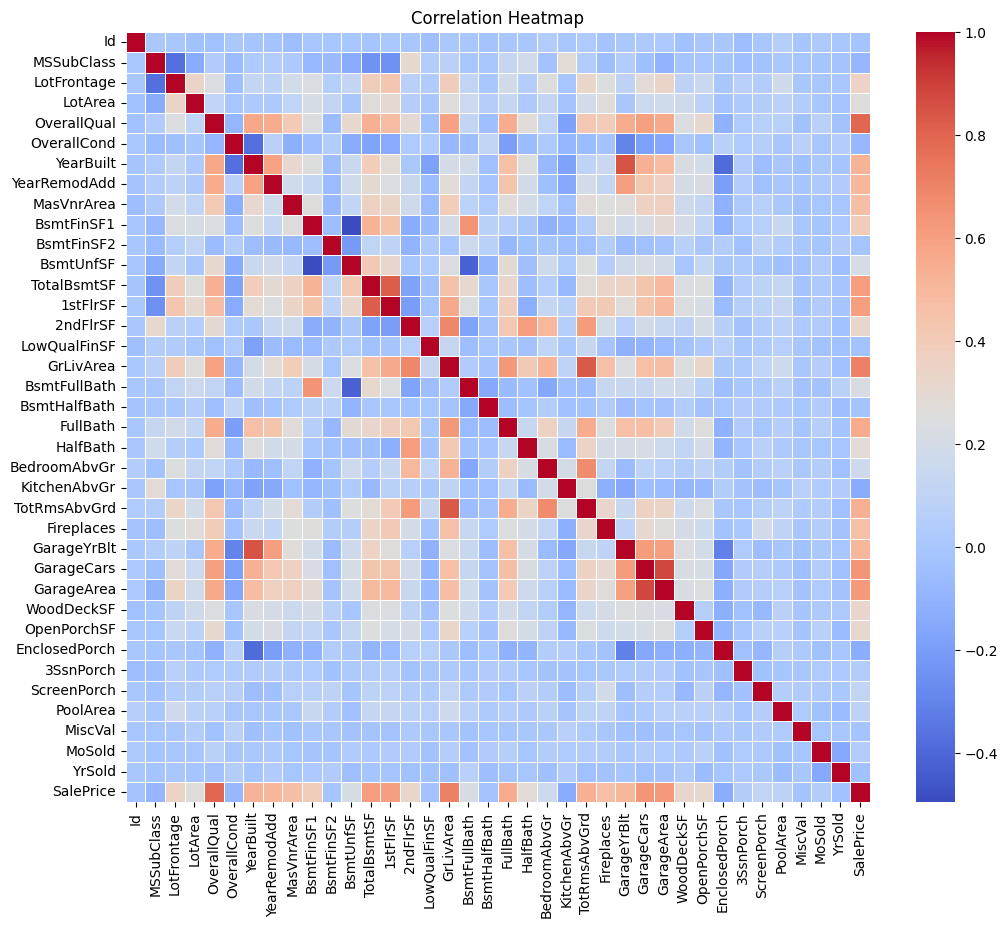

In [147]:
#Correlation heatmap for train data
plt.figure(figsize=(12, 10))
correlation_matrix = train_final.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Prediction 

In [126]:
#Importing models and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [127]:
X,y = train_final.drop(columns=['SalePrice']), train_final['SalePrice']
#Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1168, 37), (292, 37), (1168,), (292,))

In [129]:
#Simple Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
mse_lr = mean_squared_error(y_val, y_pred_lr)
r2_lr = r2_score(y_val, y_pred_lr)
print(f'Linear Regression - MSE: {mse_lr}, R2: {r2_lr}')

Linear Regression - MSE: 1358031117.412534, R2: 0.822950017935345


In [130]:
#Simple Ridge Regression Model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_val)
mse_ridge = mean_squared_error(y_val, y_pred_ridge)
r2_ridge = r2_score(y_val, y_pred_ridge)
print(f'Ridge Regression - MSE: {mse_ridge}, R2: {r2_ridge}')

Ridge Regression - MSE: 1358015580.4480932, R2: 0.8229520435290448


In [131]:
#Simple Lasso Regression Model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_val)
mse_lasso = mean_squared_error(y_val, y_pred_lasso)
r2_lasso = r2_score(y_val, y_pred_lasso)
print(f'Lasso Regression - MSE: {mse_lasso}, R2: {r2_lasso}')

Lasso Regression - MSE: 1358029373.2829564, R2: 0.8229502453219685


In [138]:
#Using XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)
mse_xgb = mean_squared_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)
print(f'XGBoost Regressor - MSE: {mse_xgb}, R2: {r2_xgb}')

XGBoost Regressor - MSE: 735569792.0, R2: 0.9041019082069397


In [139]:
#Using Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_val)
mse_gbr = mean_squared_error(y_val, y_pred_gbr)
r2_gbr = r2_score(y_val, y_pred_gbr)
print(f'Gradient Boosting Regressor - MSE: {mse_gbr}, R2: {r2_gbr}')

Gradient Boosting Regressor - MSE: 732649493.8192643, R2: 0.9044826159892954


In [140]:
#Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)
mse_rf = mean_squared_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)
print(f'Random Forest Regressor - MSE: {mse_rf}, R2 : {r2_rf}')

Random Forest Regressor - MSE: 865723481.2267935, R2 : 0.8871334206861232


In [143]:
#Let's train on whole set using XgBoost Regressor and Gradient Boosting Regressor
xgb_model_full = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model_full.fit(X, y)
#Finding MSE and R2 on validation set
y_pred_rf = xgb_model_full.predict(X_val)
mse_rf = mean_squared_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)
print(f'XGBoost Regressor (Full Data) - MSE: {mse_rf}, R2 : {r2_rf}')

XGBoost Regressor (Full Data) - MSE: 90507008.0, R2 : 0.9882003664970398


In [144]:
#Training on full data using Gradient Boosting Regressor
gbr_model_full = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbr_model_full.fit(X, y)
#Finding MSE and R2 on validation set
y_pred_gbr_full = gbr_model_full.predict(X_val)
mse_gbr_full = mean_squared_error(y_val, y_pred_gbr_full)
r2_gbr_full = r2_score(y_val, y_pred_gbr_full)
print(f'Gradient Boosting Regressor (Full Data) - MSE: {mse_gbr_full}, R2 : {r2_gbr_full}')

Gradient Boosting Regressor (Full Data) - MSE: 70562831.3267431, R2 : 0.9908005436247775


In [148]:
#Using CatBoost Regressor
from catboost import CatBoostRegressor
catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)
catboost_model.fit(X_train, y_train)
y_pred_catboost = catboost_model.predict(X_val)
mse_catboost = mean_squared_error(y_val, y_pred_catboost)
r2_catboost = r2_score(y_val, y_pred_catboost)
print(f'CatBoost Regressor - MSE: {mse_catboost}, R2: {r2_catboost}')

CatBoost Regressor - MSE: 801372370.5524583, R2: 0.8955230391894455


In [149]:
#Using CatBoost Regressor for all data
from catboost import CatBoostRegressor
catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)
catboost_model.fit(X, y)
y_pred_catboost = catboost_model.predict(X_val)
mse_catboost = mean_squared_error(y_val, y_pred_catboost)
r2_catboost = r2_score(y_val, y_pred_catboost)
print(f'CatBoost Regressor - MSE: {mse_catboost}, R2: {r2_catboost}')

CatBoost Regressor - MSE: 6463262.5326916985, R2: 0.9991573679713079


In [145]:
#Using gbr_model_full to predict on test set
test_predictions = gbr_model_full.predict(test_final)
#Formatting to match the submission file
submission = pd.DataFrame({'Id': df2['Id'],
'SalePrice': test_predictions})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,127676.308607
1,1462,152318.539653
2,1463,187008.053458
3,1464,185923.981363
4,1465,202311.066758


In [150]:
#Using gbr_model_full to predict on test set
test_predictions = catboost_model.predict(test_final)
#Formatting to match the submission file
submission = pd.DataFrame({'Id': df2['Id'],
'SalePrice': test_predictions})
submission.to_csv('submission_cat.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,127705.408702
1,1462,172167.579728
2,1463,192673.237796
3,1464,199527.607906
4,1465,183075.076270


In [151]:
#Using log transformation on SalePrice to reduce skewness
y_log = np.log1p(y)
#Training on CatBoost Regressor
from catboost import CatBoostRegressor
catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)
catboost_model.fit(X, y_log)
#Validating on val set
y_pred_log = catboost_model.predict(X_val)
mse_log = mean_squared_error(y_val, np.expm1(y_pred_log))
r2_log = r2_score(y_val, np.expm1(y_pred_log))
print(f'CatBoost Regressor with Log Transform - MSE: {mse_log}, R2: {r2_log}')

CatBoost Regressor with Log Transform - MSE: 8541646.074325947, R2: 0.9988864038055745


In [152]:
#Using same model for submission
test_predictions = catboost_model.predict(test_final)
submission = pd.DataFrame({'Id': df2['Id'],
'SalePrice': np.expm1(test_predictions)})
submission.to_csv('submission_cat_log.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,124810.086269
1,1462,159412.169113
2,1463,177108.936123
3,1464,191591.871799
4,1465,189915.106528
